<style>
  td, th {
    border: none!important;
    font-family: Arial, sans-serif;
    padding: 8px;
  }
  th {
    font-weight: bold;
  }
</style>

| Notebook Details |  |
|----|---|
|Host | Montanuniversitaet Leoben |
|Course | Mechanics of Composite Materials |
|Authors | Vasco D.C Pires |
|Department | Chair of Designing Plastics and Composite Materials|
|Corresponding Authors | vasco.castro-pires@unileoben.ac.at |
|Last edited |  17.03.2026 |

<div>
<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTWeMORYjOsTvgceJjHADfsEqLMHCPqPjUDnw&s" width="150"/>
</div>

# Python notebook - Practical Class 5

<div class="alert alert-block alert-success">
This python notebook serves as support for the pratical class about Mean Field Methods.

## Contents
***
[1) Procedure](#1-procedure)

[2) MTM Code](#2-mtm-code)


## 1) Procedure

Below the general procedure to perform a mean field homogenization is presented:

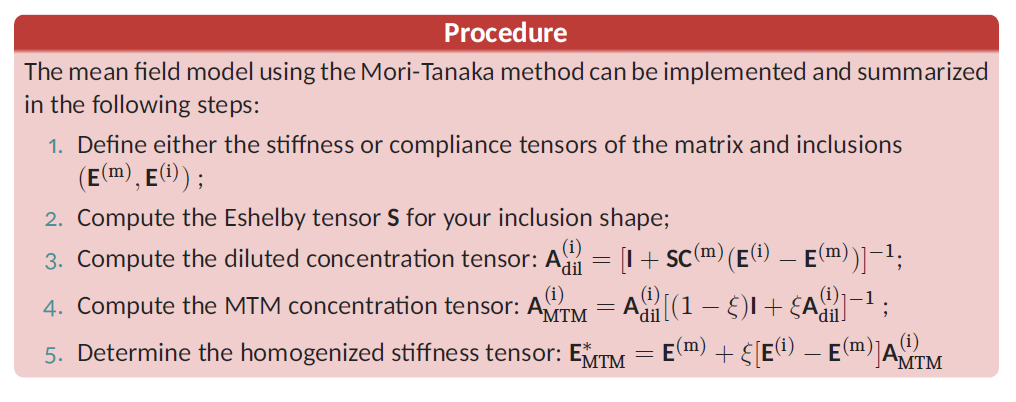

Where the stiffness tensors can be computed using:

$$
\begin{bmatrix}\varepsilon_{11}\\\varepsilon_{22}\\\varepsilon_{33}\\\gamma_{12}\\\gamma_{13}\\\gamma_{23}\end{bmatrix}
=
\begin{bmatrix}
\frac{1}{E} & -\frac{\nu}{E} & -\frac{\nu}{E} & 0 & 0 & 0 \\
-\frac{\nu}{E} & \frac{1}{E} & -\frac{\nu}{E} & 0 & 0 & 0 \\
-\frac{\nu}{E} & -\frac{\nu}{E} & \frac{1}{E} & 0 & 0 & 0 \\
0 & 0 & 0 & \frac{1}{G} & 0 & 0 \\
0 & 0 & 0 & 0 & \frac{1}{G} & 0 \\
0 & 0 & 0 & 0 & 0 & \frac{1}{G}
\end{bmatrix}
\begin{bmatrix}\sigma_{11}\\\sigma_{22}\\\sigma_{33}\\\sigma_{12}\\\sigma_{13}\\\sigma_{23}\end{bmatrix},
\qquad \mathbf{E}_{\mathrm{iso}} = \mathbf{C}_{\mathrm{iso}}^{-1}
$$

$$
\begin{bmatrix}\varepsilon_{11}\\\varepsilon_{22}\\\varepsilon_{33}\\\gamma_{12}\\\gamma_{13}\\\gamma_{23}\end{bmatrix}
=
\begin{bmatrix}
\frac{1}{E_1} & -\frac{\nu_{21}}{E_2} & -\frac{\nu_{31}}{E_3} & 0 & 0 & 0 \\
-\frac{\nu_{12}}{E_1} & \frac{1}{E_2} & -\frac{\nu_{32}}{E_3} & 0 & 0 & 0 \\
-\frac{\nu_{13}}{E_1} & -\frac{\nu_{23}}{E_2} & \frac{1}{E_3} & 0 & 0 & 0 \\
0 & 0 & 0 & \frac{1}{G_{12}} & 0 & 0 \\
0 & 0 & 0 & 0 & \frac{1}{G_{13}} & 0 \\
0 & 0 & 0 & 0 & 0 & \frac{1}{G_{23}}
\end{bmatrix}
\begin{bmatrix}\sigma_{11}\\\sigma_{22}\\\sigma_{33}\\\sigma_{12}\\\sigma_{13}\\\sigma_{23}\end{bmatrix},
\qquad \mathbf{E}_{\mathrm{ort}} = \mathbf{C}_{\mathrm{ort}}^{-1}
$$

$$
\text{where} \quad \frac{\nu_{12}}{E_1}=\frac{\nu_{21}}{E_2}, \quad \frac{\nu_{23}}{E_2}=\frac{\nu_{32}}{E_3}, \quad \frac{\nu_{13}}{E_1}=\frac{\nu_{31}}{E_3}
$$

In particular, for an transversally-isotropic material we have that:

$$ E_2 = E_3 \quad G_{12} = G_{13} \quad \nu_{12} = \nu_{23} \quad G_{23} = \frac{E_2}{2(1+\nu_{23})}$$


And the Eshelby tensor:

$$
\mathbf{S}_{a=\infty}=\begin{bmatrix}0&0&0&0&0&0\\\frac{\nu_m}{2(1-\nu_m)}&\frac{5-4\nu_m}{8(1-\nu_m)}&\frac{4\nu_m-1}{8(1-\nu_m)}&0&0&0\\\frac{\nu_m}{2(1-\nu_m)}&\frac{4\nu_m-1}{8(1-\nu_m)}&\frac{5-4\nu_m}{8(1-\nu_m)}&0&0&0\\0&0&0&0.5&0&0\\0&0&0&0&0.5&0\\0&0&0&0&0&\frac{3-4\nu_m}{4(1-\nu_m)}\end{bmatrix}
$$

## 2) MTM Code

In [43]:
# Import necessary libraries

import numpy as np

Define the Eshelby Tensor

In [44]:
def Eshelby_tensor_fiber(nu):
    """
    Computes the Eshelby tensor for a infinitely long cylinder
    Inputs:
        nu: Poisson ratio of the matrix material (matrix material must be isotropic)
    Output:
        S : Eshelby matrix (6x6 matrix)
    """
    S21 = nu/(2*(1-nu)) # = S31
    S22 = (5-4*nu)/(8*(1-nu)) # = S33
    S23 = (4*nu-1)/(8*(1-nu)) # = S32
    S66 = (3-4*nu)/(4*(1-nu))
    S = np.array([[0,0,0,0,0,0],
                    [S21,S22,S23,0,0,0],
                    [S21,S23,S22,0,0,0],
                    [0,0,0,0.5,0,0],
                    [0,0,0,0,0.5,0],
                    [0,0,0,0,0,S66]])
    return S

Computes the homogenized stiffness tensor

In [45]:
def MTM(E_m,E_i,S,xi):
    """
    Calculates the homogenized elasticity-matrix with the
    Mori-Tanaka-Method.
    inputs:
        E_m: elasticity-matrix of the matrix material (6x6)
        E_i: elasticity-matrix of the inclusion (6x6)
        S:   Eshelby-matrix (6x6)
        xi:  Volumefraction of the inclusion
    output:
        E_MTM: elasticity-matrix of the homogenized material (6x6)
    """
    # E_MTM = Em {I -xi[(Ei-Em)(S-xi(S-I))+Em]^-1 [Ei-Em]}^-1
    #                  [------------ T1 ---------]
    #            { ------------------T2----------------------}
    if xi == 0:
        return E_m
    if xi == 1:
        return E_i
    I = np.eye(6)
    Diff = E_i-E_m
    T1 = np.linalg.inv(np.dot(Diff,S-xi*(S-I))+E_m)
    T2 = np.linalg.inv(I-xi*np.dot(T1,Diff))
    E_MTM = np.dot(E_m,T2)
    return E_MTM

In [46]:
# Orthotropic material

def get_stiff_matrix_Ort(E1,E2,E3,nu12,nu13,nu23,G12,G13,G23):
    """
    Provides the compliance matrix for an orthotropic or isotropic material.

    Args:
        Elastic constants
    
    Returns:
        Compliance Matrix [C] as an numpy array
    """
    
    # Diagonal Terms
    C11 = 1/E1
    C22 = 1/E2
    C33 = 1/E3
    C44 = 1/G12
    C55 = 1/G13
    C66 = 1/G23
    
    # Off-diagonal terms
    C12 = C21 = -nu12/E1
    C13 = C31 = -nu13/E2
    C23 = C32 = -nu23/E3
    
    return np.linalg.inv(np.array([
        [C11,C12,C13,0,0,0],
        [C21,C22,C23,0,0,0],
        [C31,C32,C33,0,0,0],
        [0,0,0,C44,0,0],
        [0,0,0,0,C55,0],
        [0,0,0,0,0,C66]
    ]))


def get_stiff_matrix_Iso(E,nue):
    """
    Provides the compliance matrix for an isotropic material.

    Args:
        Elastic constant
    
    Returns:
        Compliance Matrix [C] as an numpy array
    """
    G=E/(2.*(1+nue))
    
    C11=1./E
    C22=1./E
    C33=1./E
    C12=-nue/E
    C13=-nue/E
    C21=-nue/E
    C23=-nue/E
    C31=-nue/E
    C32=-nue/E
    C44=1./G
    C55=1./G
    C66=1./G
    
    return np.linalg.inv(np.array([
        [C11,C12,C13,0,0,0],
        [C21,C22,C23,0,0,0],
        [C31,C32,C33,0,0,0],
        [0,0,0,C44,0,0],
        [0,0,0,0,C55,0],
        [0,0,0,0,0,C66]
    ]))

In [47]:
# Example case:
                            # Matrix 3501-6
                            
E_m = 4.2E3                 # Matrix Young's Modulus
poisson_m = 0.34            # Matrix Poisson

                            # Fibre AS4 (Transversely-isotropic)
E1_f = 225E3                # [MPa] Young's Modulus E1_f
E2_f = 15E3                 # [MPa] Young's Modulus E2_f
G12_f = 15E3                # [MPa] Shear Modulus G12_f
G23_f = 7E3                 # [MPa] Shear Modulus G23_f
poisson_12_f = 0.2          # [MPa] Poisson_12_f
poisson_23_f = 0.07         # [MPa] Poisson_23_f (You don't see this value parameter often for fibers. At any case, it is always small.)


Vf = 0.6


# Define the compliance of matrix
E_matrix = get_stiff_matrix_Iso(E_m, poisson_m)


# Define the compliance of fiber
E_fiber = get_stiff_matrix_Ort(E1_f,E2_f,E2_f,poisson_12_f,poisson_12_f,poisson_23_f,G12_f, G12_f, G23_f)


"""
Notice that for an isotropic fiber, you can simply use the
isotropic formulation for both the fiber and matrix.

Addapt for your case!
"""

'\nNotice that for an isotropic fiber, you can simply use the\nisotropic formulation for both the fiber and matrix.\n\nAddapt for your case!\n'

In [48]:
print(E_matrix)

[[6464.55223881 3330.2238806  3330.2238806     0.            0.
     0.        ]
 [3330.2238806  6464.55223881 3330.2238806     0.            0.
     0.        ]
 [3330.2238806  3330.2238806  6464.55223881    0.            0.
     0.        ]
 [  -0.           -0.           -0.         1567.1641791    -0.
    -0.        ]
 [   0.            0.            0.            0.         1567.1641791
     0.        ]
 [   0.            0.            0.            0.            0.
  1567.1641791 ]]


In [49]:
print(E_fiber)

[[578795.77768203  15898.31968979 116872.03791469     -0.
      -0.             -0.        ]
 [ 15898.31968979  15510.55579492   4265.4028436       0.
       0.              0.        ]
 [116872.03791469   4265.4028436   38672.98578199      0.
       0.              0.        ]
 [     0.              0.              0.          15000.
       0.              0.        ]
 [     0.              0.              0.              0.
   15000.              0.        ]
 [     0.              0.              0.              0.
       0.           7009.34579439]]


In [50]:
# Eshelby tensor

S_tensor = Eshelby_tensor_fiber(poisson_m)

In [59]:
# For a fiber volume of 60%
E_comp = MTM(E_matrix,E_fiber,S_tensor,Vf)

# Compliance of the composite
C_comp = np.linalg.inv(E_comp)


def compute_E1(Vf):
    E_comp = MTM(E_matrix, E_fiber, S_tensor, Vf)
    C_comp = np.linalg.inv(E_comp)
    return 1 / C_comp[0, 0] / 1000  # In GPa

def compute_E2(Vf):
    E_comp = MTM(E_matrix, E_fiber, S_tensor, Vf)
    C_comp = np.linalg.inv(E_comp)
    return 1 / C_comp[1, 1] / 1000  # In GPa

def compute_G12(Vf):
    E_comp = MTM(E_matrix, E_fiber, S_tensor, Vf)
    C_comp = np.linalg.inv(E_comp)
    return 1 / C_comp[3, 3] / 1000  # In GPa


print('E1', compute_E1(0.60))
print('E2', compute_E2(0.60))
#print('G12', (1/C_comp[3,3])/1000)
#print('v12', (1/C_comp[5,5]))

# Experimental Data
E1_exp = 126  # GPa
E2_exp = 11   # GPa
Vf_exp = 0.6

E1 139.92917863036485
E1 8.768255220683251


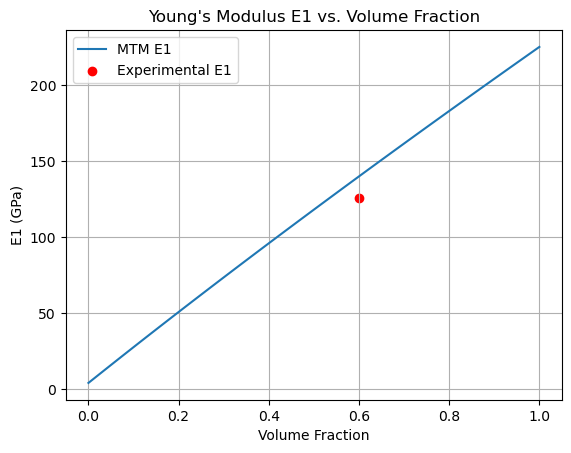

In [65]:
import matplotlib.pyplot as plt

# Plot MTM

# Define the range of volume fractions
volume_fractions = np.linspace(0, 1, 100)  # 100 points from 0 to 1

# Compute E1 for each volume fraction
E1_values = [compute_E1(Vf) for Vf in volume_fractions]

# Plot E1 vs. volume fractions
plt.plot(volume_fractions, E1_values, label='MTM E1')
plt.scatter(Vf_exp, E1_exp, color='red', label='Experimental E1')
plt.xlabel('Volume Fraction')
plt.ylabel('E1 (GPa)')
plt.title('Young\'s Modulus E1 vs. Volume Fraction')
plt.legend()
plt.grid(True)
plt.show()



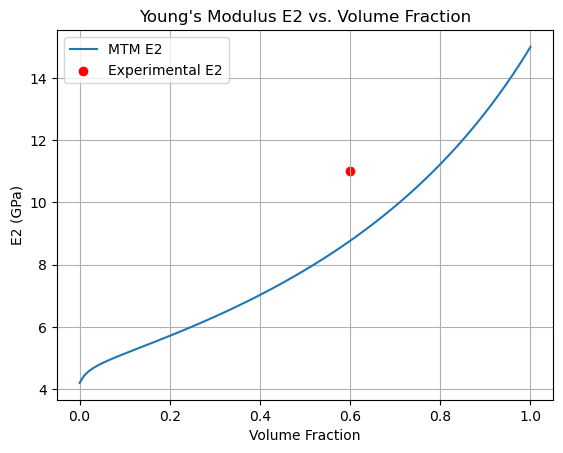

In [63]:
# Compute E2 for each volume fraction
E2_values = [compute_E2(Vf) for Vf in volume_fractions]

# Plot E1 vs. volume fractions
plt.plot(volume_fractions, E2_values, label='MTM E2')
plt.xlabel('Volume Fraction')
plt.ylabel('E2 (GPa)')
plt.title('Young\'s Modulus E2 vs. Volume Fraction')

plt.scatter(Vf_exp, E2_exp, color='red', label='Experimental E2')
plt.legend()
plt.grid(True)
plt.show()
